In [124]:
from sklearn.datasets import fetch_openml
import pandas as pd

adult = fetch_openml(name="adult", version=2, as_frame=True)
data = adult.frame   # a single DataFrame with all features AND the target column together

data.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


# Mandatory Assignment - 2
## Exercise-1: Data Preparation
### Q1.1
 Identify and quantify missing values per feature. Determine whether the missingness looks random or is concentrated in specific subgroups (e.g., check if missing
occupation correlates with workclass). Choose and justify a strategy for handling
them (e.g., imputation vs. removal, and which imputation statistic), and explain
any risks your chosen strategy introduces.

In [125]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


Here we can see that there are some features that are missing some values.

In [126]:
missing = data.isna().sum()
missing_pct = (missing / len(data) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})[missing > 0]

,missing_count,missing_%
workclass,2799,5.73
occupation,2809,5.75
native-country,857,1.75


This shows us that there are some how many that are missing from each the features. 

In [127]:
pd.crosstab(data['workclass'].isna(), data['occupation'].isna())

occupation,False,True
workclass,,
False,46033,10
True,0,2799


By Cross-tabulating missing  `workclass` against missing `occupation`, 
shows us that the all the missing values from `workclass` (2799) are 
also missing in `occupation`. 

My hypothesis is that: individuals with no reported employment status 
naturally have no occupation to report either

A separate, much smaller group of 10 rows has occupation missing despite 
workclass being present, likely reflecting genuine non-response to that 
specific question rather than the same underlying cause.

The best solution to fix this issue is to impute/create a new explicit 
category ("Unknown" or "Not-in-workforce") rather than most-frequent-category 
or removing rows. This will prevent removing valueble information that might 
correlate later with income. I also see for my self that it is bad practice 
assigning hese individuals to whatever category happens to be most common. 

For `native-country` (only 1.75% missing), imputing with the mode 
("United-States", which dominates this column) is reasonable since the
missing fraction is small and unlikely to meaningfully bias results either way.


### Q1.3
Several categorical features are high-cardinality (e.g., native-country, occupation).
Quantify the cardinality of each categorical feature and propose a strategy for the
high-cardinality ones (e.g., grouping rare categories into an ”other” bucket, fre-
quency thresholding). Justify your chosen threshold and show how it changes the
category counts. 

In [128]:
cat_cols = data.select_dtypes(include='category').columns
cardinality = data[cat_cols].nunique().sort_values(ascending=False)
print(cardinality)

native-country    41
education         16
occupation        14
workclass          8
marital-status     7
relationship       6
race               5
sex                2
class              2
dtype: int64


Here can we see how many see how many `native-country` has a high-cardinality 
(Since it has 41 different categories). `Occupation` in the other hand has also 
a high cardinality, but less than the . 

The code bellow will show the categories and the count of each of `native-country` and `Occupation`: 


In [129]:
data['native-country'].value_counts(normalize=True).head(10) * 100

native-country
United-States    91.345212
Mexico            1.981869
Philippines       0.614775
Germany           0.429301
Puerto-Rico       0.383453
Canada            0.379285
El-Salvador       0.323018
India             0.314682
Cuba              0.287590
England           0.264666
Name: proportion, dtype: float64

In [130]:
data['native-country'].value_counts()

native-country
United-States                 43832
Mexico                          951
Philippines                     295
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Guatemala                        88
Poland                           87
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                         67
Taiwan                           65
Iran                             59
Greece                           49
Nicaragua                        49
Peru                             46
Ecuador      

From this we can see that the US alone accounts for around 90% of all rows,
While mexico has around 1-2%. The rest is under 1%. 

Lets try to reduse it to 3 category. This can be done by creating a threshold 
from 1%:

In [131]:
threshold = 0.01  # keep a category only if it makes up at least 1% of all rows

# get each country's share of the total rows (normalize=True gives proportions, not raw counts)
value_counts = data['native-country'].value_counts(normalize=True)

# countries below the threshold - these are the ones we'll group together
rare_categories = value_counts[value_counts < threshold].index

# create a new column: keep common countries as-is, replace rare ones with "Other"
data['native-country_grouped'] = data['native-country'].apply(
    lambda x: 'Other' if x in rare_categories else x
)


print("Before:", data['native-country'].nunique(), "categories")   # original number of countries
print("After: ", data['native-country_grouped'].nunique(), "categories")  # fewer, now that rare ones are merged
print("\nCategories after grouping:")
print(data['native-country_grouped'].value_counts())

Before: 41 categories
After:  3 categories

Categories after grouping:
native-country_grouped
United-States    43832
Other             3202
Mexico             951
Name: count, dtype: int64



Applying a 1% frequency threshold reduces `native-country` from 41 categories down to
just 3: `United-States` (43,832 rows, around 91%), `Other` (3,202 rows, grouping all
countries individually below 1%), and `Mexico` (951 rows, around 2%).

This removes countries with only a handful of rows each, which the model could barely
learn from anyway, and avoids the risk of a country showing up in the test set that
the model never saw during training.

The trade-off: countries like Germany or Canada, which might have their own real
income pattern, now get lumped into "Other" along with everyone else. Since each of
these groups is very small on its own, we're likely not losing much. But it's worth
knowing this simplification could hide a real pattern if one of these countries
mattered more than expected.

In [132]:
print(data['workclass'].unique(),"\n")
print(data['workclass'].value_counts())

['Private', 'Local-gov', NaN, 'Self-emp-not-inc', 'Federal-gov', 'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked']
Categories (8, str): ['Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay'] 

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64


### Q1.4

Encode the categorical features using an appropriate technique (e.g., one-hot encoding, target encoding, or ordinal encoding where suitable) and justify your choice.
Discuss how the encoding affects the dimensionality of the feature space, and how
it interacts with your high-cardinality strategy from the previous question.


For the nominal categorical features (`workclass`, `marital-status`, `occupation`,
`relationship`, `race`, `native-country_grouped`), **OneHotEncoder** is the most
appropriate choice.

None of these features have a natural order. For example, `workclass` values like
`Private`, `Self-emp-not-inc`, and `Federal-gov` aren't points on a scale, and the
same is true for the other features. Ordinal encoding would falsely imply an order
between them, for example, encoding `race` as 0-4 would suggest one category lies
"between" two others, which has no real meaning here. One-hot encoding avoids this by
giving each category its own independent binary column.

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# --- 1. Impute missing values (safe to re-run: checks before adding categories) ---
if 'Unknown' not in data['workclass'].cat.categories:
    data['workclass'] = data['workclass'].cat.add_categories('Unknown')
data['workclass'] = data['workclass'].fillna('Unknown')

if 'Unknown' not in data['occupation'].cat.categories:
    data['occupation'] = data['occupation'].cat.add_categories('Unknown')
data['occupation'] = data['occupation'].fillna('Unknown')

data['native-country'] = data['native-country'].fillna(data['native-country'].mode()[0])

print("Missing values after imputation:")
print(data[['workclass', 'occupation', 'native-country']].isna().sum())

# --- 2. Recreate native-country_grouped from the now-imputed native-country ---
threshold = 0.01
value_counts = data['native-country'].value_counts(normalize=True)
rare_categories = value_counts[value_counts < threshold].index
data['native-country_grouped'] = data['native-country'].apply(
    lambda x: 'Other' if x in rare_categories else x
)

# --- 3. Verify everything is clean before encoding ---
nominal_cols = ['workclass', 'marital-status', 'occupation',
                'relationship', 'race', 'native-country_grouped']
print("\nMissing values in nominal columns:")
print(data[nominal_cols].isna().sum())

# --- 4. One-hot encode ---
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_array = encoder.fit_transform(data[nominal_cols])

print("\nBefore encoding:", data[nominal_cols].shape[1], "columns")
print("After encoding: ", encoded_array.shape[1], "columns")

# --- 5. Assemble the final feature matrix X and target y ---
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(nominal_cols),
    index=data.index
)

sex_encoded = data['sex'].map({'Male': 0, 'Female': 1})

numeric_cols = data.select_dtypes(include='number').columns.tolist()
X = pd.concat([data[numeric_cols], sex_encoded.rename('sex'), encoded_df], axis=1)
y = data['class'].map({'<=50K': 0, '>50K': 1})

print("\nFinal X shape:", X.shape)
print("Final y shape:", y.shape)



Missing values after imputation:
workclass         0
occupation        0
native-country    0
dtype: int64

Missing values in nominal columns:
workclass                 0
marital-status            0
occupation                0
relationship              0
race                      0
native-country_grouped    0
dtype: int64

Before encoding: 6 columns
After encoding:  39 columns

Final X shape: (48842, 46)
Final y shape: (48842,)
workclass         0
occupation        0
native-country    0
dtype: int64
3
39
(48842, 46) (48842,)


After imputing missing values (since i nearly forgot to...) and grouping rare native-country categories, one-hot
encoding the 6 nominal features increases the feature space from 6 to 39 columns.
Adding the numeric features and the binary sex column gives a final feature matrix
with 46 columns. This shows why the native-country grouping mattered: without
reducing it from 41 to 3 categories first, one-hot encoding would have added about
40 extra columns from that feature alone.

##### Binary Feature Encoding: `class` and `sex`

Unlike the nominal features above, `class` (the target) and `sex` (a feature)
are each binary, they only take on two possible values. For these,
**one-hot encoding is unnecessary and wasteful**, so a direct mapping to 0/1
is used instead.

In [134]:
print(data['sex'].unique()) 

['Male', 'Female']
Categories (2, str): ['Female', 'Male']


In [135]:
data['sex'] = data['sex'].map({'Male': 0, 'Female': 1})

print(data['sex'].unique(), "\n")
print(data['sex'].value_counts())

[0, 1]
Categories (2, int64): [1, 0] 

sex
0    32650
1    16192
Name: count, dtype: int64


In [136]:
print(data['class'].unique(),"\n")
print(data['class'].value_counts())

['<=50K', '>50K']
Categories (2, str): ['<=50K', '>50K'] 

class
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [137]:
y = data['class'].map({'<=50K': 0, '>50K': 1})
X = data.drop(columns=['class'])

Why not one hot encode these too?

With only two categories, one hot encoding would create two columns that
mirror each other completely. For example, sex_Male and sex_Female would
always be opposite values, so one column already tells you the other. This
adds an extra column with no new information, increases dimensionality for
no reason, and creates multicollinearity, which is especially bad for
models like SVM that are sensitive to correlated features. A single 0/1
column keeps the same information using half the columns.

For class specifically, since it is the target variable and not an input
feature, it is never included in the encoding process applied to the
feature columns. It is mapped separately and stored as y, so it cannot
accidentally end up inside the feature matrix X, which would otherwise
cause target leakage.

Dimensionality impact: while one hot encoding increased the nominal
features from 6 columns to 40, mapping sex to 0/1 keeps it at exactly
1 column, the same as before encoding. This shows the main point of this
question clearly: the encoding method should match the structure of the
feature instead of using one hot encoding everywhere.

**Target encoding** is generally more useful for
features with very high cardinality, where one-hot would cause a large increase
in dimensionality. Since none of these features have that problem, especially
after grouping `native-country`, one-hot encoding is preferable: it is more
interpretable, avoids the target leakage risk inherent to target encoding, and
does not require additional safeguards like smoothing or cross-validation.

### Q1.5 
Compute a correlation matrix (or association measure suitable for mixed types,
e.g., Cramer’s V for categorical pairs) among the features. Plot it as a heatmap
and identify any pairs with strong multicollinearity. Discuss why multicollinearity
is a concern for a linear SVM but less so for a Decision Tree


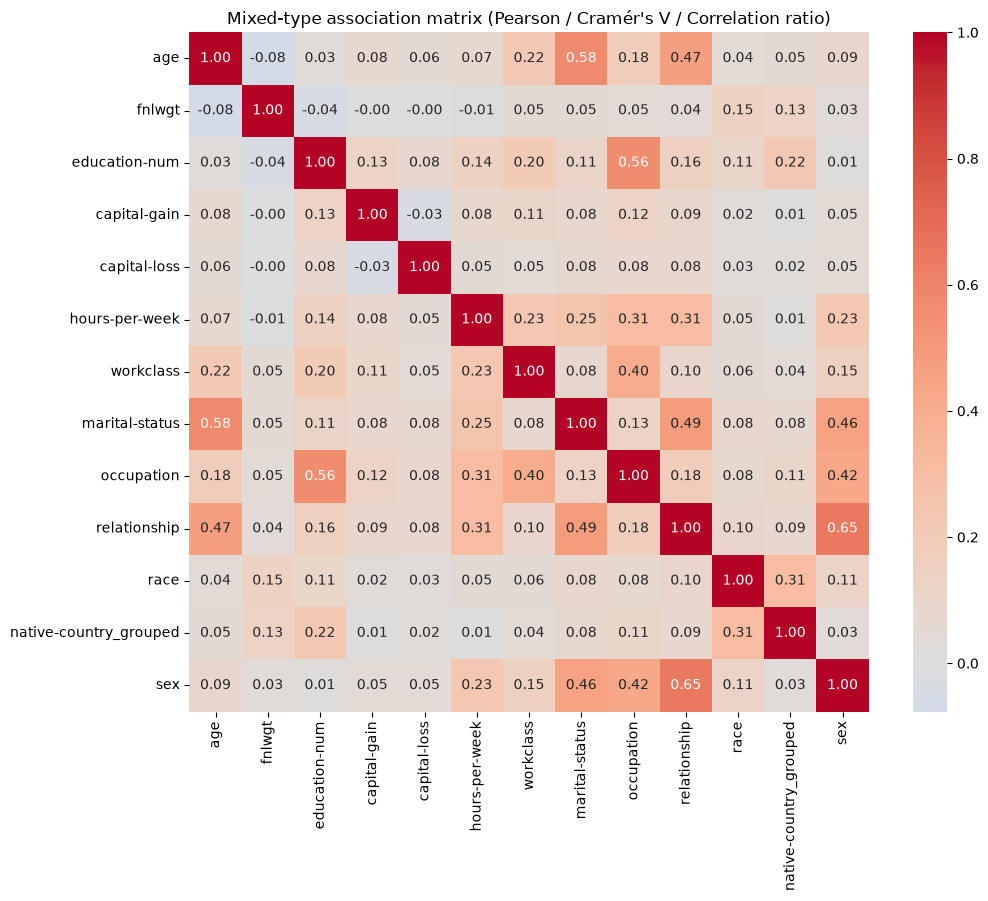

In [139]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

def correlation_ratio(categories, values):
    categories = pd.Series(categories)
    values = pd.Series(values)
    cat_means = values.groupby(categories).mean()
    overall_mean = values.mean()
    n_per_cat = categories.value_counts()
    ss_between = sum(n_per_cat[cat] * (mean - overall_mean) ** 2 for cat, mean in cat_means.items())
    ss_total = sum((values - overall_mean) ** 2)
    return np.sqrt(ss_between / ss_total)

numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'native-country_grouped', 'sex']

all_cols = numeric_cols + categorical_cols
assoc_matrix = pd.DataFrame(index=all_cols, columns=all_cols, dtype=float)

for col1 in all_cols:
    for col2 in all_cols:
        if col1 == col2:
            assoc_matrix.loc[col1, col2] = 1.0
        elif col1 in numeric_cols and col2 in numeric_cols:
            assoc_matrix.loc[col1, col2] = data[col1].corr(data[col2])
        elif col1 in categorical_cols and col2 in categorical_cols:
            assoc_matrix.loc[col1, col2] = cramers_v(data[col1], data[col2])
        else:
            num_col, cat_col = (col1, col2) if col1 in numeric_cols else (col2, col1)
            assoc_matrix.loc[col1, col2] = correlation_ratio(data[cat_col], data[num_col])

plt.figure(figsize=(11, 9))
sns.heatmap(assoc_matrix.astype(float), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Mixed-type association matrix (Pearson / Cramér\'s V / Correlation ratio)')
plt.tight_layout()
plt.show()